## Split Distribution Check (Train / Validation / Test)

Before training **MelCNN MGR**, we should sanity-check that the **genre proportions** across **train**, **validation**, and **test** are not wildly different. In this project, our working meaning of **“same distribution shape”** is:

> The **ratios of samples per genre** (class proportions) in train/val/test are **roughly similar**, so evaluation isn’t distorted by one split containing disproportionately more (or fewer) samples from certain genres.
>
> In other words, in MelCNN MGR project, it’s preferable (though not strictly required) that train/validation/test have similar genre proportions, because it reduces the chance that performance differences are driven by a different class mix rather than MFCC vs log-mel (Goal 1) or optimization choices (Goal 2). Since FMA provides an official split in fma_metadata/tracks.csv, the best practice is to use that split for comparability and to avoid leakage traps, then measure and report genre proportions as a “distribution-shape” sanity check. If proportions differ noticeably, the evaluation remains valid, but results should emphasize Macro-F1 and per-genre F1, and may optionally use class-weighted loss.




### What we will compute

Using FMA metadata (`tracks.csv`), where:
- split is stored in `('set', 'split')` ∈ {`training`, `validation`, `test`}
- genre label is stored in `('track', 'genre_top')`

We will compute:

1) **Counts per genre per split**  
   A table like: rows = genres, columns = {train, val, test}

2) **Proportions per genre per split**  
   Same table but normalized so each split sums to 1.

3) **Drift ratios** (easy to interpret)  
   For each genre `g`, compute:
   - `p_test(g) / p_train(g)`
   - `p_val(g)  / p_train(g)`
   
   Values near **1.0** mean the split proportions match closely.
   Large deviations suggest distribution shift in class mix.

4) **One-number distance summaries** (optional but useful)
- **Total Variation Distance (TVD)**:  
  \[
  \text{TVD}(p, q) = \frac{1}{2}\sum_g |p(g) - q(g)|
  \]
  where `p(g)` and `q(g)` are genre proportions in two splits.

- **Jensen–Shannon Divergence (JSD)** (symmetric + stable):
  a bounded measure of how different two distributions are.

### How we will compare

We’ll use:
- A **bar chart** (genre proportions across splits) for quick visual sanity.
- A **drift ratio table** to spot which genres differ most.
- (Optional) TVD/JSD to summarize “how different” the splits are with a single value.

### Interpretation

- Minor differences are normal and acceptable.
- If some genres have big drift (e.g., 2× higher in test than train), metrics like **accuracy** can be misleading.
- That’s why we will report **Macro-F1** and **per-genre F1** (not just accuracy), since FMA-medium is unbalanced.

This check does **not** change the official FMA split; it simply makes our evaluation assumptions explicit and auditable.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Load metadata (adjust path)
tracks = pd.read_csv("../../FMA/fma_metadata/tracks.csv", header=[0,1], index_col=0)

Counts:
 split                test  training  validation
genre                                          
Blues                  13        88           9
Classical              87      1069          74
Country                18       158          18
Easy Listening          6        15           3
Electronic            839      7662         871
Experimental         1085      8557         966
Folk                  299      2275         229
Hip-Hop               323      2910         319
Instrumental          309      1579         191
International         128      1124         137
Jazz                   47       462          62
Old-Time / Historic    55       445          54
Pop                   204      1815         313
Rock                 1464     11394        1324
Soul-RnB               43       112          20
Spoken                 31       278         114

Proportions:
 split                    test  training  validation
genre                                              
Blues   

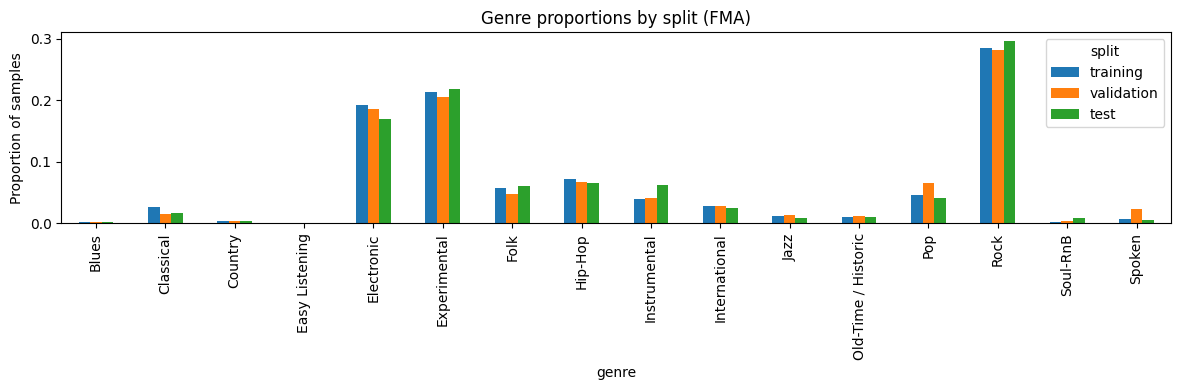


Drift ratios (closer to 1 is better):
                      test/train  val/train
genre                                     
Classical              0.656582   0.587797
Jazz                   0.820736   1.139523
Electronic             0.883421   0.965271
Hip-Hop                0.895483   0.930831
Spoken                 0.899631   3.482037
Pop                    0.906779   1.464337
International          0.918737   1.034970
Country                0.919101   0.967361
Old-Time / Historic    0.997127   1.030403
Experimental           1.022954   0.958581
Rock                   1.036603   0.986700
Folk                   1.060321   0.854727
Blues                  1.191814   0.868427
Instrumental           1.578789   1.027128
Soul-RnB               3.097406   1.516301
Easy Listening         3.227065   1.698257

TVD(train, val):  0.044093030272219544
TVD(train, test): 0.048814748857962845
JSD(train, val):  0.006750397359012998
JSD(train, test): 0.004856651814523141


In [7]:



# Keep only the columns we need
df = tracks[[("set","split"), ("track","genre_top")]].dropna()
df.columns = ["split", "genre"]

# 1) Counts and proportions
counts = pd.crosstab(df["genre"], df["split"]).sort_index()
props = counts / counts.sum(axis=0)

print("Counts:\n", counts)
print("\nProportions:\n", props)

# 2A) Plot proportions
ax = props[["training","validation","test"]].plot(kind="bar", figsize=(12,4))
ax.set_ylabel("Proportion of samples")
ax.set_title("Genre proportions by split (FMA)")
plt.tight_layout()
plt.show()

# 2B) Per-genre drift ratios (test/train, val/train)
drift = pd.DataFrame({
    "test/train": props["test"] / props["training"],
    "val/train":  props["validation"] / props["training"],
})
print("\nDrift ratios (closer to 1 is better):\n", drift.sort_values("test/train"))

# 2C) Distances: TVD and JSD
def tvd(p, q):
    return 0.5 * np.abs(p - q).sum()

def jsd(p, q, eps=1e-12):
    # Jensen-Shannon divergence (base 2)
    p = np.clip(p, eps, 1); p = p / p.sum()
    q = np.clip(q, eps, 1); q = q / q.sum()
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * np.log2(p / m))
    kl_qm = np.sum(q * np.log2(q / m))
    return 0.5 * (kl_pm + kl_qm)

genres = props.index
p_train = props["training"].reindex(genres).fillna(0).to_numpy()
p_val   = props["validation"].reindex(genres).fillna(0).to_numpy()
p_test  = props["test"].reindex(genres).fillna(0).to_numpy()

print("\nTVD(train, val): ", tvd(p_train, p_val))
print("TVD(train, test):", tvd(p_train, p_test))
print("JSD(train, val): ", jsd(p_train, p_val))
print("JSD(train, test):", jsd(p_train, p_test))

---

# Result interpretation

## MelCNN MGR — Split Distribution Similarity Report (Train / Validation / Test)

### Context and purpose

This report summarizes the **genre distribution** across the **training**, **validation**, and **test** splits observed in this notebook, and evaluates how well the splits satisfy the project’s “same distribution shape” assumption—defined here as **roughly similar genre ratios** across splits. This matters because large differences in class mix can confound comparisons between **MFCC vs log-mel** (Goal 1) and later optimization experiments (Goal 2).

---

### 1) Split overview: dominant genre proportions are stable

The dataset’s “core mass” is consistently distributed across splits. The largest genres remain the same and their proportions are close:

* **Rock** dominates across all splits:

  * Train **28.53%**, Validation **28.15%**, Test **29.57%**

* **Experimental** and **Electronic** are also major genres and remain stable:

  * Experimental: Train **21.42%**, Validation **20.54%**, Test **21.91%**
  * Electronic: Train **19.18%**, Validation **18.52%**, Test **16.95%**

**Interpretation:** The majority of the dataset’s probability mass sits in a few high-frequency genres, and those genres are distributed similarly across train/validation/test. This is a strong signal that the split is broadly representative for model training and evaluation.

---

### 2) Notable deviations: drift ratios highlight a few shifts

While most genres remain close, the drift ratio analysis (test/train and val/train) identifies several genres whose proportions differ more noticeably:

* **Instrumental**: Test/Train **1.58×**

  * Train **3.95%** → Test **6.24%**

* **Spoken**: Val/Train **3.48×**

  * Train **0.70%** → Validation **2.42%**

* **Pop**: Val/Train **1.46×**

  * Train **4.54%** → Validation **6.65%**

* **Classical**: lower in validation and test

  * Test/Train **0.66×**, Val/Train **0.59×**
  * Train **2.68%** → Test **1.76%**, Validation **1.57%**

Additionally, very small classes can show large ratios due to tiny counts, even when absolute differences are small:

* **Easy Listening**: Test/Train **3.23×** (very small absolute change)

  * ~**0.04%** → ~**0.12%**

* **Soul-RnB**: Test/Train **3.10×**

  * Train **0.28%** → Test **0.87%**

**Interpretation:** Some differences reflect real shifts (notably Spoken in validation, Instrumental in test, and Pop in validation). However, for very rare genres, large ratio changes can be misleading because the baseline proportion is extremely small.

---

### 3) Overall similarity: distance metrics indicate splits are close

Two global distribution distance measures were computed:

* **Total Variation Distance (TVD)**

  * TVD(Train, Validation) = **0.0441**
  * TVD(Train, Test) = **0.0488**

* **Jensen–Shannon Divergence (JSD)**

  * JSD(Train, Validation) = **0.00675**
  * JSD(Train, Test) = **0.00486**

**Interpretation:**

* **TVD ≈ 0.045–0.049** is small in practice: only about **4.5–4.9%** of probability mass would need to be “reassigned” across genres to make the distributions match perfectly.
* **JSD ≈ 0.005–0.007** is also small, supporting the conclusion that the split distributions are broadly similar.

---

### 4) Conclusion: “same distribution shape” holds well enough for MelCNN MGR

Overall, the train/validation/test splits exhibit **broadly similar genre proportions**, especially for the dominant genres that drive most learning signal. There are a few **notable deviations** (Spoken in validation, Instrumental in test, Pop in validation, Classical lower in validation/test), but the global similarity metrics indicate the splits remain **close overall**.

---

### Practical implications for MelCNN MGR

1. **Using the official FMA split is appropriate** and remains the best practice for comparability and leakage avoidance.
2. Because the dataset is unbalanced and minor drift exists, evaluation should emphasize **Macro-F1 and per-genre F1**, not accuracy alone.
3. **Class-weighted loss** is a reasonable optional enhancement (especially in Goal 2), but there is no need to “fix” the split to proceed—your experimental setup remains valid and clean.
